<a href="https://colab.research.google.com/github/Suman18-bit/Data-Analysis-Projects/blob/main/netflix_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [240]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [241]:
df = pd.read_csv("mymoviedb.csv", engine='python', on_bad_lines='skip')

In [242]:
df.head(2)

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...


In [243]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9837 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9837 non-null   object 
 1   Title              9828 non-null   object 
 2   Overview           9828 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   object 
 5   Vote_Average       9827 non-null   object 
 6   Original_Language  9827 non-null   object 
 7   Genre              9826 non-null   object 
 8   Poster_Url         9826 non-null   object 
dtypes: float64(1), object(8)
memory usage: 691.8+ KB


In [244]:
df['Vote_Average'] = pd.to_numeric(df['Vote_Average'], errors='coerce')

In [245]:
df['Vote_Count'] = pd.to_numeric(df['Vote_Count'], errors='coerce')

In [246]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9837 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9837 non-null   object 
 1   Title              9828 non-null   object 
 2   Overview           9828 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9826 non-null   float64
 5   Vote_Average       9826 non-null   float64
 6   Original_Language  9827 non-null   object 
 7   Genre              9826 non-null   object 
 8   Poster_Url         9826 non-null   object 
dtypes: float64(3), object(6)
memory usage: 691.8+ KB


In [247]:
df['Release_Date'] = pd.to_datetime(df['Release_Date'], errors='coerce')

In [248]:
df['Release_Date'] = df['Release_Date'].dt.year.astype('Int64')

In [249]:
df.head(2)

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940.0,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151.0,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...


In [250]:
col= ['Overview','Original_Language','Poster_Url']
df=df.drop(col,axis = 1)

In [251]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940.0,8.3,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151.0,8.1,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122.0,6.3,Thriller
3,2021,Encanto,2402.201,5076.0,7.7,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793.0,7.0,"Action, Adventure, Thriller, War"


In [252]:
df['Genre'] = df['Genre'].fillna('')
df['Genre'] = df['Genre'].str.split(', ')
df = df.explode('Genre').reset_index(drop=True)

In [253]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940.0,8.3,Action
1,2021,Spider-Man: No Way Home,5083.954,8940.0,8.3,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940.0,8.3,Science Fiction
3,2022,The Batman,3827.658,1151.0,8.1,Crime
4,2022,The Batman,3827.658,1151.0,8.1,Mystery


In [254]:
print(df['Popularity'].max())
print(df['Popularity'].min())
df=df.dropna()

5083.954
7.1


In [255]:
df['Popularity'].describe()

,Popularity
count,25792.000000
mean,42.000539
std,113.343183
min,13.354000
25%,16.365750
50%,21.862000
75%,36.503000
max,5083.954000


In [256]:
df['Vote_Average_Labels'] = pd.qcut(df['Vote_Average'], q=4, labels=False, duplicates='drop')
label_mapping = {
    0: 'below average',
    1: 'average',
    2: 'good',
    3: 'very good'
}

df['Vote_Average'] = df['Vote_Average_Labels'].map(label_mapping)

In [257]:
df.head(1)

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre,Vote_Average_Labels
0,2021,Spider-Man: No Way Home,5083.954,8940.0,very good,Action,3


In [258]:
df.head(1)

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre,Vote_Average_Labels
0,2021,Spider-Man: No Way Home,5083.954,8940.0,very good,Action,3


In [259]:
df.head(1)

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre,Vote_Average_Labels
0,2021,Spider-Man: No Way Home,5083.954,8940.0,very good,Action,3


In [260]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25792 entries, 0 to 25802
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Release_Date         25792 non-null  Int64  
 1   Title                25792 non-null  object 
 2   Popularity           25792 non-null  float64
 3   Vote_Count           25792 non-null  float64
 4   Vote_Average         25792 non-null  object 
 5   Genre                25792 non-null  object 
 6   Vote_Average_Labels  25792 non-null  int64  
dtypes: Int64(1), float64(2), int64(1), object(3)
memory usage: 1.6+ MB


In [261]:
df = df.drop_duplicates()

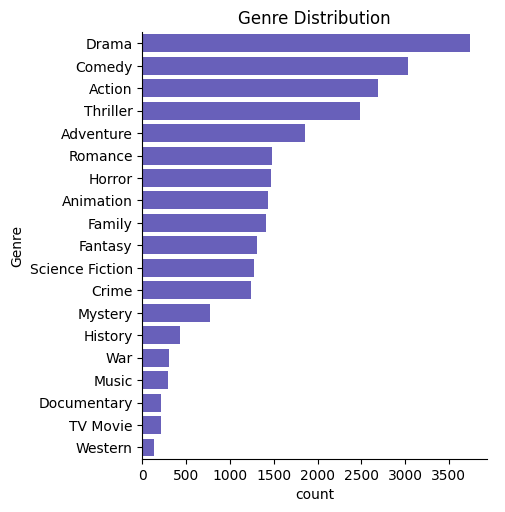

In [262]:
sns.catplot(y='Genre',data=df,kind='count',
            order=df['Genre'].value_counts().index,
            color='#5b51c98c')
plt.title('Genre Distribution')
plt.show()

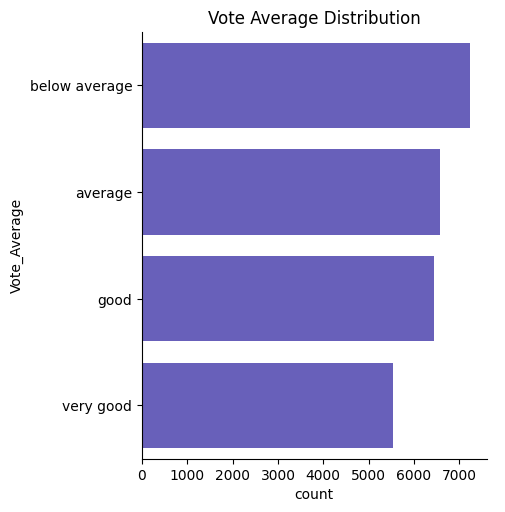

In [263]:
sns.catplot(y='Vote_Average',data=df,kind='count',
            order=df['Vote_Average'].value_counts().index,
            color='#5b51c98c')
plt.title('Vote Average Distribution')
plt.show()

# Most Popular Show

In [264]:
df[df['Popularity']==df['Popularity'].max()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre,Vote_Average_Labels
0,2021,Spider-Man: No Way Home,5083.954,8940.0,very good,Action,3
1,2021,Spider-Man: No Way Home,5083.954,8940.0,very good,Adventure,3
2,2021,Spider-Man: No Way Home,5083.954,8940.0,very good,Science Fiction,3


# Least Popular Show

In [265]:
df[df['Popularity']==df['Popularity'].min()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre,Vote_Average_Labels
25797,2021,The United States vs. Billie Holiday,13.354,152.0,good,Music,2
25798,2021,The United States vs. Billie Holiday,13.354,152.0,good,Drama,2
25799,2021,The United States vs. Billie Holiday,13.354,152.0,good,History,2
25800,1984,Threads,13.354,186.0,very good,War,3
25801,1984,Threads,13.354,186.0,very good,Drama,3
25802,1984,Threads,13.354,186.0,very good,Science Fiction,3


## In Which Year Most of Movie Released

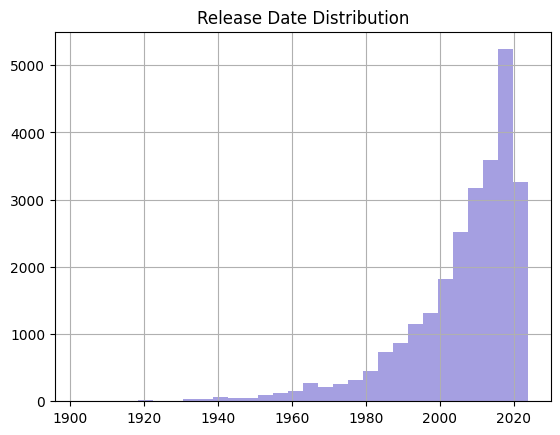

In [266]:
df['Release_Date'].hist(bins=30, color='#5b51c98c')
plt.title('Release Date Distribution')
plt.show()